
A minimal runnable script that:
  * loads/creates placeholder organoid graphs,
  * builds the dataset,
  * trains with the two-phase sparse procedure,
  * prints evaluation metrics and top coefficients,
  * saves history to disk for later plotting.


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data


In [47]:
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import load_aux_metadata_for_dir, attach_metadata_to_graphs

# Load all organoids
data_dir = PROJECT_ROOT / "training_data" / "full_set"
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(
    graphs,
    meta,
    exclude_keys=["graph_path", "seg_path"],
)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

Loaded 1224 graphs; skipped 0.
Loaded 1224 organoids.
Attached metadata to 1224/1224 graphs.


In [48]:
# from src.data.metadata import filter_graphs_by_metadata

# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     drop_values=["day4", "day4p5-more"],
# )

# print(f"After timepoint filter: {len(graphs)} organoids.")

In [49]:
from src.data.metadata import ensure_metadata_keys

graphs = ensure_metadata_keys(
    graphs,
    required_keys=["complexity", "dataset", "timepoint", "num_nodes"],
    defaults={
        "complexity": np.nan,
        "dataset": None,
        "timepoint": None,
        "num_nodes": np.nan,
    },
    inplace=False,
)


complexities = np.array([
    np.nan if getattr(g, "meta", {}).get("complexity", None) is None
    else float(getattr(g, "meta", {}).get("complexity"))
    for g in graphs
], dtype=float)

mask_keep = (~np.isfinite(complexities)) | (complexities >= 1.0)

graphs = [g for g, keep in zip(graphs, mask_keep) if keep]

print(f"After complexity filter: {len(graphs)} organoids.")

After complexity filter: 881 organoids.


In [50]:
from src.data.preprocessing import subtract_organoid_mean_curvature, robust_zscore_organoid_targets

graphs = subtract_organoid_mean_curvature(graphs, inplace=False)
# graphs = robust_zscore_organoid_targets(graphs, inplace=False)


In [51]:
from src.data.metadata import strip_graph_metadata
from src.data.splits import standardize_graph_targets, train_val_split_graphs

graphs = strip_graph_metadata(graphs, inplace=False)


# Split dataset by organoid
g_train, g_val = train_val_split_graphs(graphs, val_frac=0.2, seed=None)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

center, scale = standardize_graph_targets(g_train, g_val, robust=True)

Split -> train: 705 | val: 176


In [52]:
from src.training.loop import TrainConfig, train

cfg = TrainConfig(
    loss_name="gaussian",
    lr=1e-3,
    batch_size=128,
    max_epochs=500,
    patience=100,
    num_workers=4,
)

In [53]:
from src.data.ring_features import attach_precomputed_ring_features

K_MAX = 9


g_train = attach_precomputed_ring_features(
    g_train,
    k_hops=K_MAX,
    inplace=False,
)

g_val = attach_precomputed_ring_features(
    g_val,
    k_hops=K_MAX,
    inplace=False,
)

In [54]:
from pathlib import Path
import numpy as np
import pandas as pd

from src.models.gnn import (
    PureSAGECurvature,
    GINCurvature,
    GATCurvature,
    JKGraphSAGECurvature,
    count_parameters,
)
from src.models.ring_mlp import RingFractionMLP, PooledKHopMLP
from src.models.io import save_model_checkpoint

SAVE_FLAG = True
scan_name = "scan_depth_multi_all"
save_root = PROJECT_ROOT / "models" / scan_name

depths = np.arange(0, K_MAX)

base_hidden_dim = 4*64
base_dropout = 0.1
base_norm = "batch"

trained_model_families = {
    "GraphSAGE": [],
    "GIN": [],
    "GAT": [],
    "JKsage": [],
    "ring": [],
    "pooled": [],
}

param_rows = []

for family in trained_model_families.keys():
    family_root = save_root / family

    for k in depths:
        print(f"\n=== Training {family} model with depth={k} ===")

        n_markers = int(g_train[0].x.size(1))

        if family == "GraphSAGE":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
            }
            model = PureSAGECurvature(**model_kwargs)

        elif family == "GIN":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
                "train_eps": True,
            }
            model = GINCurvature(**model_kwargs)

        elif family == "GAT":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
                "heads": 4,
                "attn_dropout": 0.0,
            }
            model = GATCurvature(**model_kwargs)

        elif family == "JKsage":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
                "jk_mode": "cat",
            }
            model = JKGraphSAGECurvature(**model_kwargs)

        elif family == "ring":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "feature_attr": "x_ring",
            }
            model = RingFractionMLP(**model_kwargs)

        elif family == "pooled":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "feature_attr": "x_ring",
                "include_center": True,
            }
            model = PooledKHopMLP(**model_kwargs)

        else:
            raise ValueError(f"Unknown family: {family}")

        n_params_trainable = count_parameters(model, trainable_only=True)
        n_params_total = count_parameters(model, trainable_only=False)

        param_rows.append({
            "family": family,
            "depth": int(k),
            "model_class": type(model).__name__,
            "n_params_trainable": n_params_trainable,
            "n_params_total": n_params_total,
        })

        print(f"Parameters: trainable={n_params_trainable:,} | total={n_params_total:,}")

        model, metrics, history = train(model, g_train, g_val, cfg)
        trained_model_families[family].append(model)

        if SAVE_FLAG:
            save_path = family_root / f"model_depth_{k}.pt"

            save_model_checkpoint(
                path=save_path,
                model=model,
                optimizer=None,
                epoch=len(history["train_loss"]),
                metrics=metrics,
                config={
                    "model_family": family,
                    "model_class": type(model).__name__,
                    "model_kwargs": model_kwargs,
                    "train_config": vars(cfg),
                    "n_params_trainable": n_params_trainable,
                    "n_params_total": n_params_total,
                },
            )

            print(f"Saved → {save_path}")

param_df = pd.DataFrame(param_rows)
display(param_df)


=== Training GraphSAGE model with depth=0 ===
Parameters: trainable=2,562 | total=2,562
epoch 001 | train loss 1.2327 mae 0.9897 | val loss 1.0187 mae 0.9664
epoch 002 | train loss 1.0579 mae 0.9871 | val loss 0.9361 mae 0.9677
epoch 003 | train loss 0.9827 mae 0.9871 | val loss 0.8957 mae 0.9645
epoch 004 | train loss 0.9378 mae 0.9844 | val loss 0.8777 mae 0.9586
epoch 005 | train loss 0.9155 mae 0.9813 | val loss 0.8687 mae 0.9547
epoch 006 | train loss 0.9022 mae 0.9803 | val loss 0.8629 mae 0.9545
epoch 007 | train loss 0.8918 mae 0.9810 | val loss 0.8562 mae 0.9563
epoch 008 | train loss 0.8834 mae 0.9825 | val loss 0.8486 mae 0.9593
epoch 009 | train loss 0.8765 mae 0.9845 | val loss 0.8420 mae 0.9628
epoch 010 | train loss 0.8706 mae 0.9847 | val loss 0.8373 mae 0.9626
epoch 011 | train loss 0.8677 mae 0.9837 | val loss 0.8347 mae 0.9619
epoch 012 | train loss 0.8645 mae 0.9823 | val loss 0.8327 mae 0.9618
epoch 013 | train loss 0.8629 mae 0.9815 | val loss 0.8321 mae 0.9622
e

,family,depth,model_class,n_params_trainable,n_params_total
0,GraphSAGE,0,PureSAGECurvature,2562,2562
1,GraphSAGE,1,PureSAGECurvature,72450,72450
2,GraphSAGE,2,PureSAGECurvature,204290,204290
3,GraphSAGE,3,PureSAGECurvature,336130,336130
4,GraphSAGE,4,PureSAGECurvature,467970,467970
5,GraphSAGE,5,PureSAGECurvature,599810,599810
6,GraphSAGE,6,PureSAGECurvature,731650,731650
7,GraphSAGE,7,PureSAGECurvature,863490,863490
8,GraphSAGE,8,PureSAGECurvature,995330,995330
9,GIN,0,GINCurvature,2562,2562


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.inference.predict import predict_targets
from src.analysis.marker_stats import compute_markerwise_residuals, estimate_marker_conditional_gaussians
from src.analysis.prediction_analysis import rescale_distribution_outputs, compute_markerwise_uncertainty_correlation, compute_global_uncertainty_correlation
from src.data.metadata import load_marker_names_from_dir

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
marker_names = load_marker_names_from_dir(str(data_dir))


def compute_nodewise_nll(y, mu, var, eps=1e-12):
    y = np.asarray(y, dtype=np.float64)
    mu = np.asarray(mu, dtype=np.float64)
    var = np.asarray(var, dtype=np.float64)
    var = np.maximum(var, eps)
    return 0.5 * (np.log(var) + (y - mu) ** 2 / var)


def compute_markerwise_nll(y_true, mu_model, log_var_model, X, eps=1e-12):
    y_true = np.asarray(y_true, dtype=np.float64).reshape(-1)
    mu_model = np.asarray(mu_model, dtype=np.float64).reshape(-1)
    log_var_model = np.asarray(log_var_model, dtype=np.float64).reshape(-1)
    X = np.asarray(X)

    M = X.shape[1]
    n_pos = np.zeros(M, dtype=np.int64)

    mu_pos, var_pos, mu_none, var_none = estimate_marker_conditional_gaussians(y_true, X)

    var_pos = np.asarray(var_pos, dtype=np.float64)
    var_pos = np.maximum(var_pos, eps)

    var_model = np.exp(log_var_model).astype(np.float64)
    var_model = np.maximum(var_model, eps)

    nll_model_list, nll_base_list = [], []
    Delta_mean_list, Delta_var_list = [], []

    for m in range(M):
        mask = X[:, m] > 0.5
        n = int(np.sum(mask))
        n_pos[m] = n

        if n == 0:
            nll_model_list.append(np.zeros((0,), dtype=np.float64))
            nll_base_list.append(np.zeros((0,), dtype=np.float64))
            Delta_mean_list.append(np.zeros((0,), dtype=np.float64))
            Delta_var_list.append(np.zeros((0,), dtype=np.float64))
            continue

        y_m = y_true[mask]
        mu_m = mu_model[mask]
        var_m = var_model[mask]

        mu_b = float(mu_pos[m])
        var_b = float(var_pos[m])

        nll_m = compute_nodewise_nll(y_m, mu_m, var_m).astype(np.float64)
        nll_b = compute_nodewise_nll(y_m, mu_b, var_b).astype(np.float64)

        nll_model_list.append(nll_m)
        nll_base_list.append(nll_b)

        Delta_var = 0.5 * np.log(var_b / var_m)
        Delta_mean = 0.5 * ((y_m - mu_b) ** 2 / var_b - (y_m - mu_m) ** 2 / var_m)

        Delta_mean_list.append(Delta_mean.astype(np.float64))
        Delta_var_list.append(Delta_var.astype(np.float64))

    return nll_model_list, nll_base_list, Delta_mean_list, Delta_var_list, n_pos


def eval_model_per_marker(model, g_val, device, scale, center, eps=1e-12):
    """
    Evaluate predictive performance and uncertainty calibration of a model
    on a validation graph, aggregated per marker.

    The function runs the model to obtain predictive means and variances,
    rescales outputs back to the original data space, and computes a range
    of marker-wise metrics. These include mean squared error (MSE) and
    negative log-likelihood (NLL) for both the model and a baseline,
    standard errors of these estimates, average predicted variance,
    and diagnostics quantifying how predictive uncertainty correlates
    with squared residuals. It also reports differences in mean and
    variance relative to the baseline.

    Returns a dictionary containing all marker-level performance,
    uncertainty, and calibration statistics, as well as global
    uncertainty–error correlation measures.
    """
        
    y, mu, log_var, X = predict_targets(
        g_val,
        model,
        device=device,
        return_log_var=True,
    )

    y, mu, log_var = rescale_distribution_outputs(
        y, mu, log_var=log_var, center=center, scale=scale
    )
    var = np.exp(log_var)

    residuals_model, residuals_base, n_pos_resid, mu_pos_resid = compute_markerwise_residuals(y, mu, X)

    mse_model = np.array([np.mean(r**2) if r.size > 0 else np.nan for r in residuals_model])
    mse_base = np.array([np.mean(r**2) if r.size > 0 else np.nan for r in residuals_base])

    sem_mse_model = np.array([
        np.std(r**2, ddof=1) / np.sqrt(r.size) if r.size > 1 else np.nan
        for r in residuals_model
    ])
    sem_mse_base = np.array([
        np.std(r**2, ddof=1) / np.sqrt(r.size) if r.size > 1 else np.nan
        for r in residuals_base
    ])

    Xb = X > 0.5
    var_model = np.array([
        np.mean(var[Xb[:, m]]) if np.any(Xb[:, m]) else np.nan
        for m in range(X.shape[1])
    ])
    sem_var_model = np.array([
        np.std(var[Xb[:, m]], ddof=1) / np.sqrt(np.sum(Xb[:, m]))
        if np.sum(Xb[:, m]) > 1 else np.nan
        for m in range(X.shape[1])
    ])

    var_base = mse_base
    sem_var_base = sem_mse_base

    nll_model_list, nll_base_list, delta_mean_list, delta_var_list, n_pos_nll = compute_markerwise_nll(
        y_true=y,
        mu_model=mu,
        log_var_model=log_var,
        X=X,
        eps=eps,
    )

    nll_model = np.array([np.mean(v) if v.size > 0 else np.nan for v in nll_model_list])
    nll_base = np.array([np.mean(v) if v.size > 0 else np.nan for v in nll_base_list])

    sem_nll_model = np.array([
        np.std(v, ddof=1) / np.sqrt(v.size) if v.size > 1 else np.nan
        for v in nll_model_list
    ])
    sem_nll_base = np.array([
        np.std(v, ddof=1) / np.sqrt(v.size) if v.size > 1 else np.nan
        for v in nll_base_list
    ])

    delta_mean = np.array([np.mean(v) if v.size > 0 else np.nan for v in delta_mean_list])
    delta_var = np.array([np.mean(v) if v.size > 0 else np.nan for v in delta_var_list])

    # --- uncertainty / squared-residual correlation ---
    rho_marker, pval_marker, n_pos_corr = compute_markerwise_uncertainty_correlation(
        y=y,
        mu=mu,
        log_var=log_var,
        X=X,
    )

    rho_global, pval_global = compute_global_uncertainty_correlation(
        y=y,
        mu=mu,
        log_var=log_var,
    )

    return {
        "mse_model": mse_model,
        "sem_mse_model": sem_mse_model,
        "mse_base": mse_base,
        "sem_mse_base": sem_mse_base,
        "var_model": var_model,
        "sem_var_model": sem_var_model,
        "var_base": var_base,
        "sem_var_base": sem_var_base,
        "nll_model": nll_model,
        "sem_nll_model": sem_nll_model,
        "nll_base": nll_base,
        "sem_nll_base": sem_nll_base,
        "delta_mean": delta_mean,
        "delta_var": delta_var,
        "rho_marker": rho_marker,
        "pval_marker": pval_marker,
        "n_pos_corr": n_pos_corr,
        "rho_global": rho_global,
        "pval_global": pval_global,
    }


depths = np.asarray(depths)

all_results = {}

for family, models in trained_model_families.items():
    fam_mse_model = []
    fam_sem_mse_model = []
    fam_var_model = []
    fam_sem_var_model = []
    fam_nll_model = []
    fam_sem_nll_model = []
    fam_rho_marker = []
    fam_pval_marker = []
    fam_n_pos_corr = []
    fam_rho_global = []
    fam_pval_global = []

    fam_mse_base = None
    fam_var_base = None
    fam_sem_mse_base = None
    fam_nll_base = None
    fam_sem_nll_base = None

    for model in models:
        model.eval()
        out = eval_model_per_marker(model, g_val, device, scale, center)

        fam_mse_model.append(out["mse_model"])
        fam_sem_mse_model.append(out["sem_mse_model"])
        fam_var_model.append(out["var_model"])
        fam_sem_var_model.append(out["sem_var_model"])
        fam_nll_model.append(out["nll_model"])
        fam_sem_nll_model.append(out["sem_nll_model"])
        fam_rho_marker.append(out["rho_marker"])
        fam_pval_marker.append(out["pval_marker"])
        fam_n_pos_corr.append(out["n_pos_corr"])
        fam_rho_global.append(out["rho_global"])
        fam_pval_global.append(out["pval_global"])

        if fam_mse_base is None:
            fam_mse_base = out["mse_base"]
            fam_var_base = out["var_base"]
            fam_sem_mse_base = out["sem_mse_base"]
            fam_nll_base = out["nll_base"]
            fam_sem_nll_base = out["sem_nll_base"]

    all_results[family] = {
        "mse_model": np.stack(fam_mse_model, axis=0),
        "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
        "var_model": np.stack(fam_var_model, axis=0),
        "sem_var_model": np.stack(fam_sem_var_model, axis=0),
        "nll_model": np.stack(fam_nll_model, axis=0),
        "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
        "rho_marker": np.stack(fam_rho_marker, axis=0),
        "pval_marker": np.stack(fam_pval_marker, axis=0),
        "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
        "rho_global": np.asarray(fam_rho_global, dtype=float),
        "pval_global": np.asarray(fam_pval_global, dtype=float),
        "mse_base": fam_mse_base,
        "var_base": fam_var_base,
        "sem_mse_base": fam_sem_mse_base,
        "nll_base": fam_nll_base,
        "sem_nll_base": fam_sem_nll_base,
    }

In [60]:
# ---- choose markers to plot ----
marker_names = load_marker_names_from_dir(str(data_dir))


print(marker_names)

selected_marker_names = marker_names # <-- change to your markers
name_to_idx = {n: i for i, n in enumerate(marker_names)}
selected_idx = [name_to_idx[n] for n in selected_marker_names]


DEFAULT_MARKER_COLORS = {
    "Agr2": "#359BD5",
    "Lysozyme": "#2C75D2",
    "Mucin 2": "#3EC1D9",
    "Chroma": "#D852CB",
    "Glucagon": "#983EE2",
    "Serotonin": "#F392E3",
    "LGR5": "#FFB431",
    "AldoB": "#F16C6A",
    "Cyclin D": "#808080",
    "Cyclin A": "#808080",
    "KI67": "#808080",
    "other": "#EBEBEB",
}

baseline_color = "#888888"

def get_marker_color(name):
    return DEFAULT_MARKER_COLORS.get(name, DEFAULT_MARKER_COLORS["other"])

['LGR5', 'Chroma', 'AldoB', 'Agr2', 'Serotonin', 'Lysozyme', 'KI67']


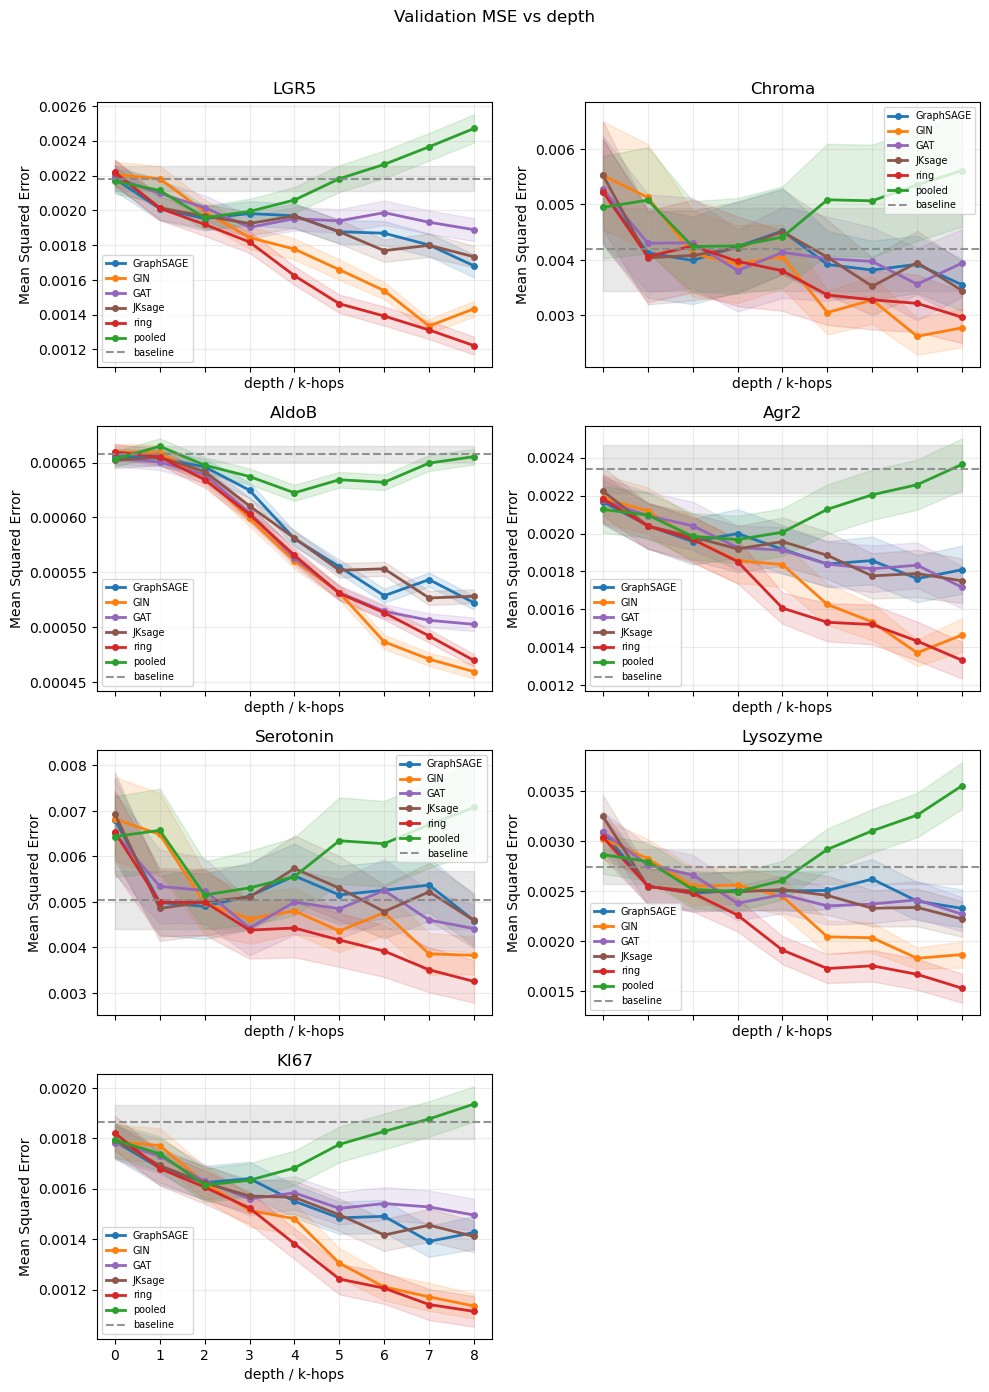

In [61]:
import math
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

family_colors = {
    "GraphSAGE": "#1f77b4",
    "GIN":       "#ff7f0e",
    "GAT":       "#9467bd",
    "JKsage":    "#8c564b",
    "ring":      "#d62728",
    "pooled":    "#2ca02c",
}

family_order = [
    "GraphSAGE",
    "GIN",
    "GAT",
    "JKsage",
    "ring",
    "pooled",
]

baseline_color = "#888888"

n_sel = len(selected_idx)
n_cols = 2
n_rows = math.ceil(n_sel / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 3.4 * n_rows),
    sharex=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    for family in family_order:
        if family not in all_results:
            continue

        y = all_results[family]["mse_model"][:, mi]
        s = all_results[family]["sem_mse_model"][:, mi]
        x = depths

        ax.plot(
            x, y, "-o",
            linewidth=2,
            markersize=4,
            color=family_colors[family],
            label=family,
        )
        ax.fill_between(
            x,
            y - s,
            y + s,
            color=family_colors[family],
            alpha=0.14,
        )

    # baseline is shared across families, so just take the first available one
    ref_family = next(f for f in family_order if f in all_results)
    y0 = all_results[ref_family]["mse_base"][mi]
    s0 = all_results[ref_family]["sem_mse_base"][mi]

    ax.axhline(
        y0,
        linestyle="--",
        color=baseline_color,
        alpha=0.9,
        label="baseline",
    )
    ax.fill_between(
        depths,
        y0 - s0,
        y0 + s0,
        color=baseline_color,
        alpha=0.18,
    )

    ax.set_title(mname)
    ax.set_ylabel("Mean Squared Error")
    ax.set_xlabel("depth / k-hops")
    ax.set_xticks(depths)
    ax.legend(fontsize=7)

for ax in axes[n_sel:]:
    ax.set_visible(False)

fig.suptitle("Validation MSE vs depth", y=1.02)
plt.tight_layout()
plt.show()

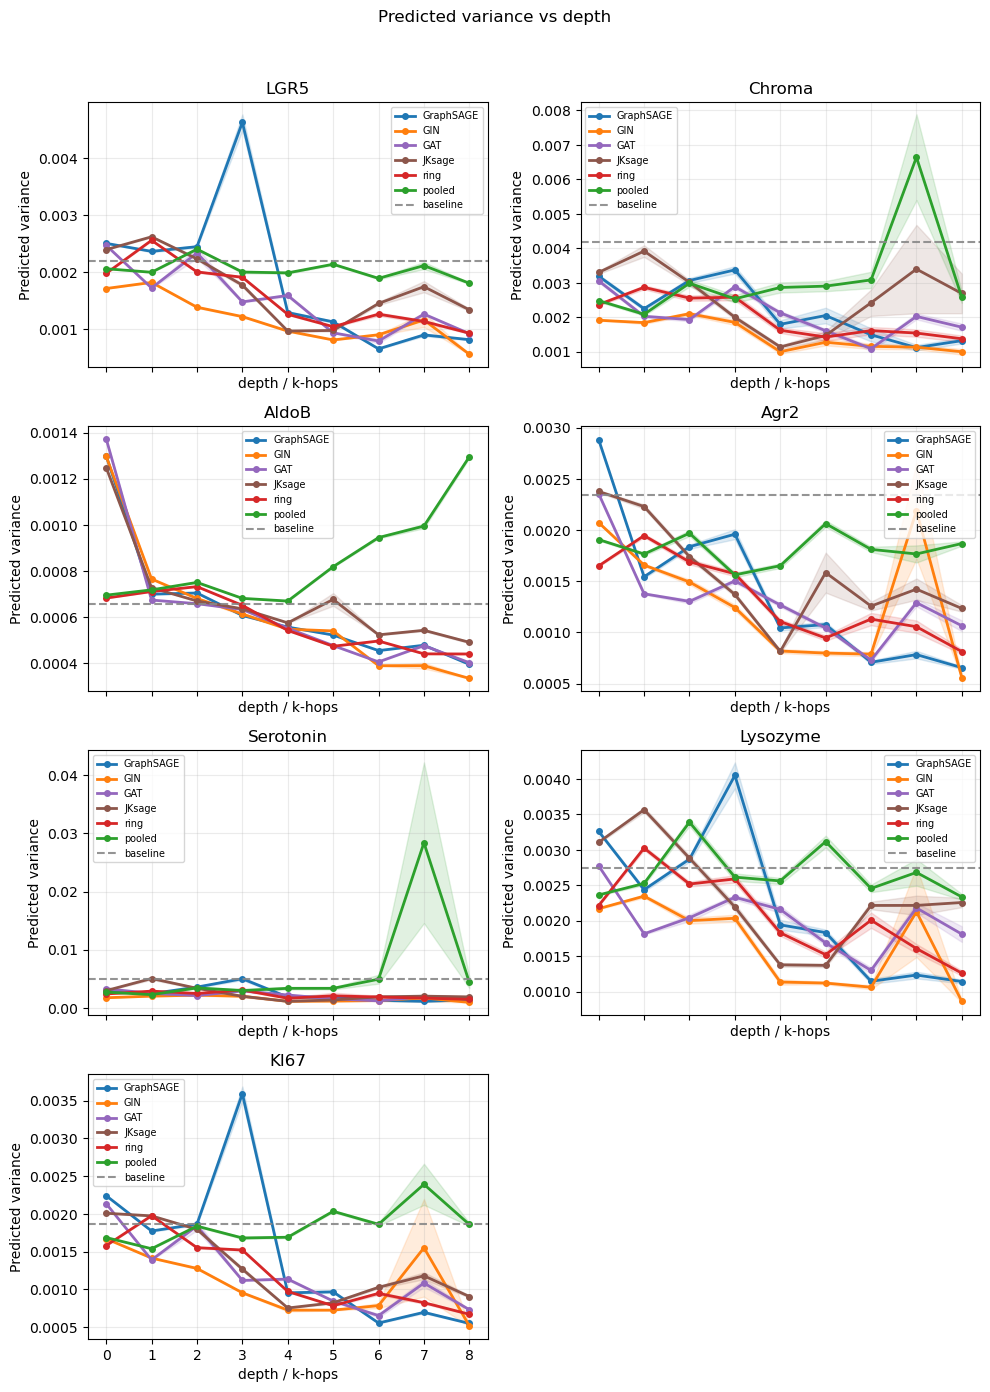

In [62]:
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 3.4 * n_rows),
    sharex=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    for family in family_order:
        if family not in all_results:
            continue

        y = all_results[family]["var_model"][:, mi]
        s = all_results[family]["sem_var_model"][:, mi]
        x = depths

        ax.plot(
            x, y, "-o",
            linewidth=2,
            markersize=4,
            color=family_colors[family],
            label=family,
        )
        ax.fill_between(
            x,
            y - s,
            y + s,
            color=family_colors[family],
            alpha=0.14,
        )

    ref_family = next(f for f in family_order if f in all_results)
    y0 = all_results[ref_family]["var_base"][mi]
    ax.axhline(
        y0,
        linestyle="--",
        color=baseline_color,
        alpha=0.9,
        label="baseline",
    )

    ax.set_title(mname)
    ax.set_ylabel("Predicted variance")
    ax.set_xlabel("depth / k-hops")
    ax.set_xticks(depths)
    ax.legend(fontsize=7)

for ax in axes[n_sel:]:
    ax.set_visible(False)

fig.suptitle("Predicted variance vs depth", y=1.02)
plt.tight_layout()
plt.show()

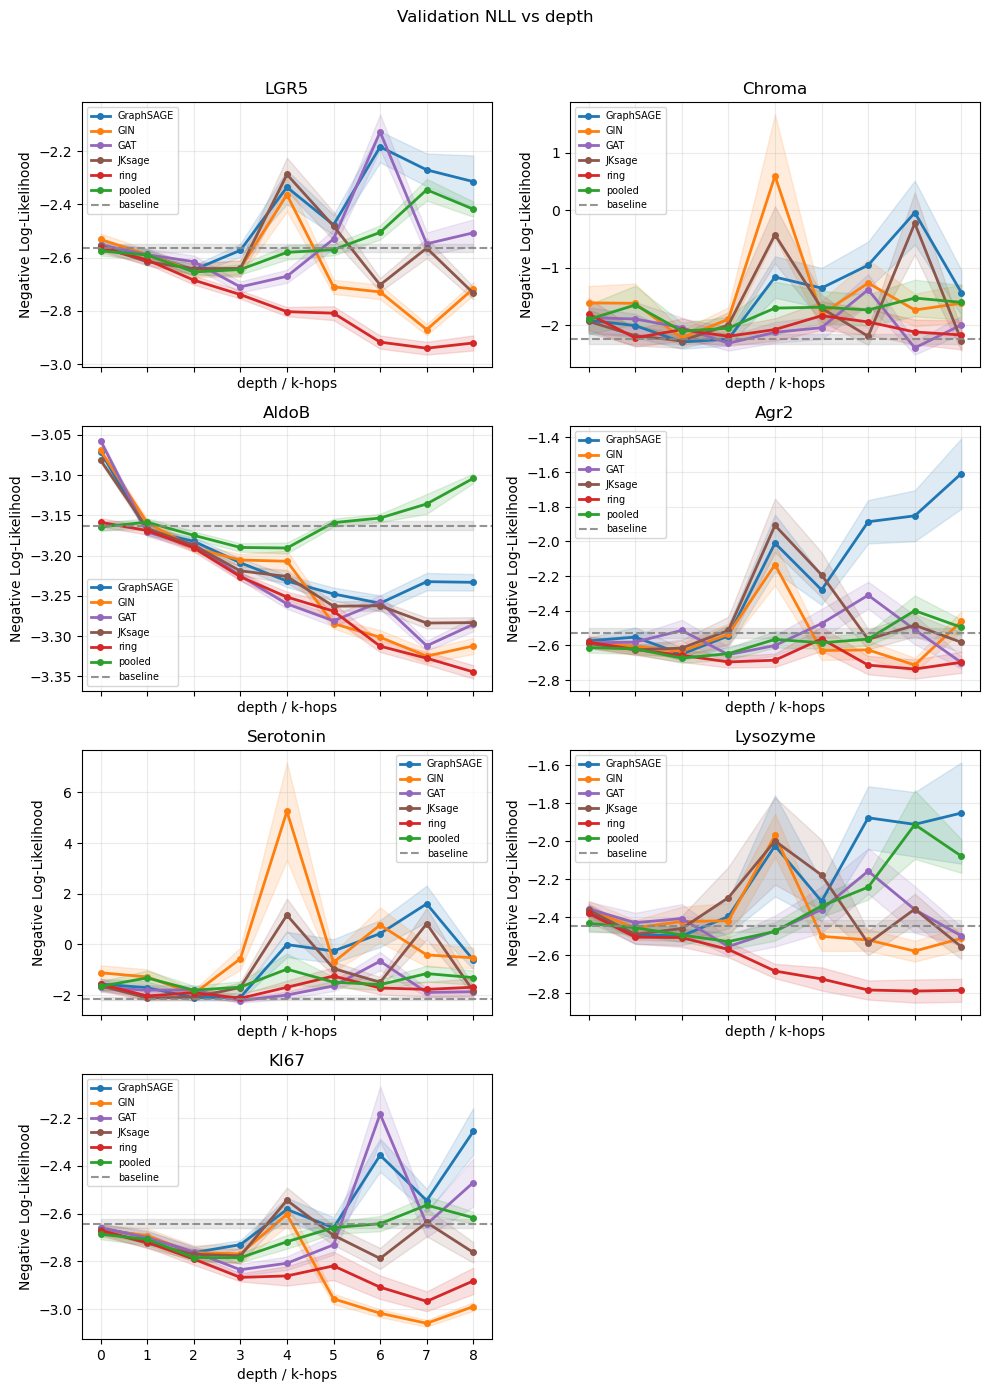

In [63]:
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 3.4 * n_rows),
    sharex=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    for family in family_order:
        if family not in all_results:
            continue

        y = all_results[family]["nll_model"][:, mi]
        s = all_results[family]["sem_nll_model"][:, mi]
        x = depths

        ax.plot(
            x, y, "-o",
            linewidth=2,
            markersize=4,
            color=family_colors[family],
            label=family,
        )
        ax.fill_between(
            x,
            y - s,
            y + s,
            color=family_colors[family],
            alpha=0.14,
        )

    ref_family = next(f for f in family_order if f in all_results)
    y0 = all_results[ref_family]["nll_base"][mi]
    s0 = all_results[ref_family]["sem_nll_base"][mi]

    ax.axhline(
        y0,
        linestyle="--",
        color=baseline_color,
        alpha=0.9,
        label="baseline",
    )
    ax.fill_between(
        depths,
        y0 - s0,
        y0 + s0,
        color=baseline_color,
        alpha=0.18,
    )

    ax.set_title(mname)
    ax.set_ylabel("Negative Log-Likelihood")
    ax.set_xlabel("depth / k-hops")
    ax.set_xticks(depths)
    ax.legend(fontsize=7)

for ax in axes[n_sel:]:
    ax.set_visible(False)

fig.suptitle("Validation NLL vs depth", y=1.02)
plt.tight_layout()
plt.show()

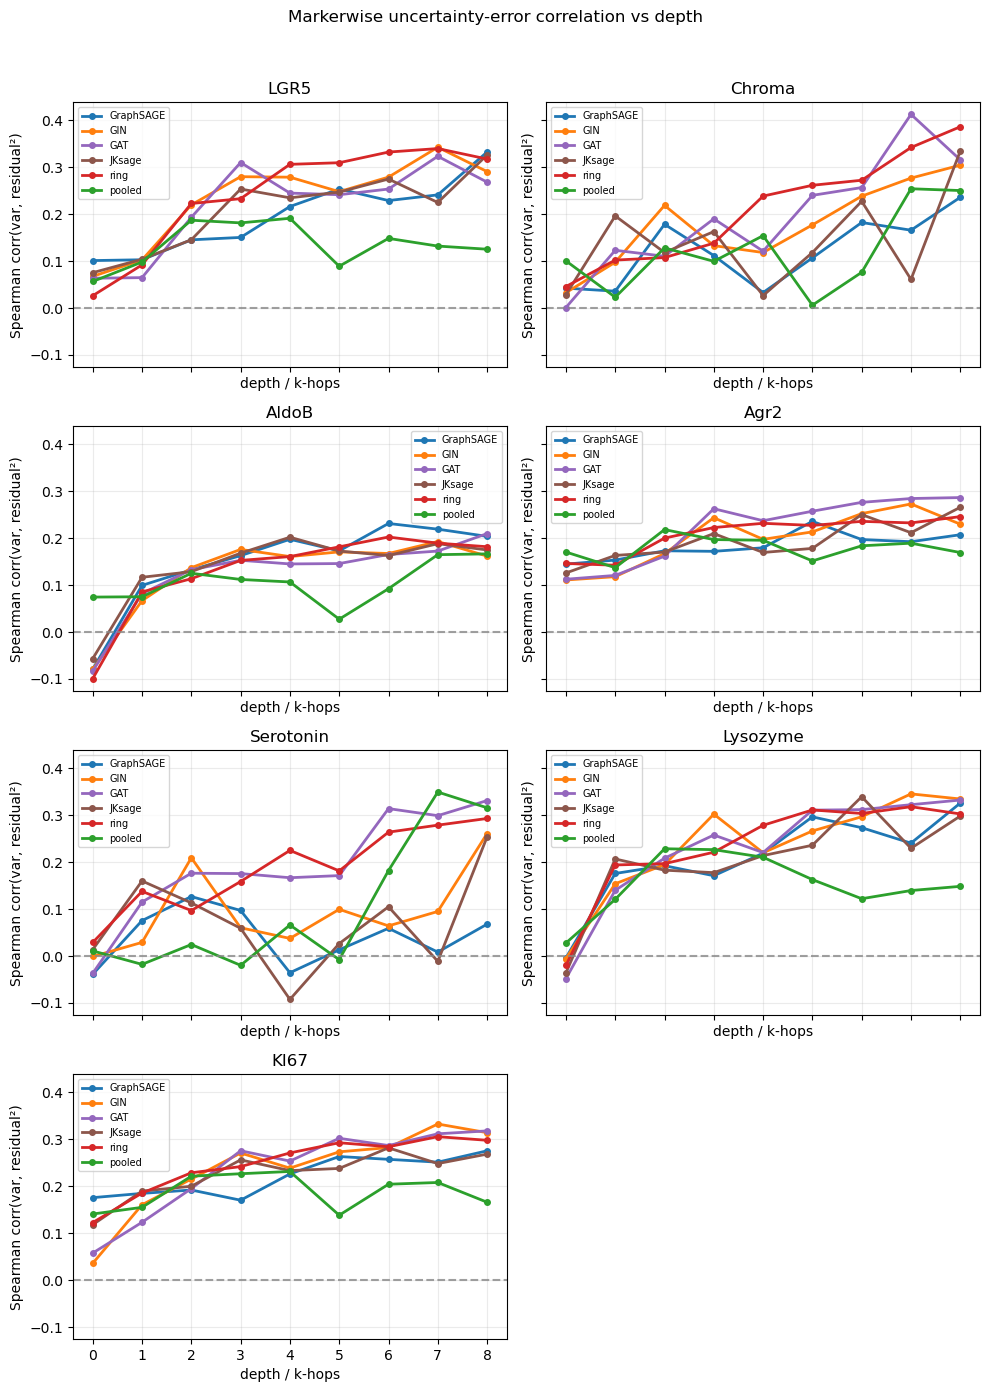

In [64]:
import math

n_sel = len(selected_idx)
n_cols = 2
n_rows = math.ceil(n_sel / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 3.4 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    for family in family_order:
        if family not in all_results:
            continue

        y = all_results[family]["rho_marker"][:, mi]
        x = depths

        ax.plot(
            x, y, "-o",
            linewidth=2,
            markersize=4,
            color=family_colors[family],
            label=family,
        )

    ax.axhline(0.0, linestyle="--", color="#888888", alpha=0.8)

    ax.set_title(mname)
    ax.set_ylabel("Spearman corr(var, residual²)")
    ax.set_xlabel("depth / k-hops")
    ax.set_xticks(depths)
    ax.legend(fontsize=7)

for ax in axes[n_sel:]:
    ax.set_visible(False)

fig.suptitle("Markerwise uncertainty-error correlation vs depth", y=1.02)
plt.tight_layout()
plt.show()

In [65]:
for family in family_order:
    if family not in all_results:
        continue
    print(f"\n{family}")
    for d, rho, p in zip(depths, all_results[family]["rho_global"], all_results[family]["pval_global"]):
        print(f"depth={int(d):2d}  rho_global={rho: .3f}  p={p: .2e}")


GraphSAGE
depth= 0  rho_global= 0.071  p= 2.98e-81
depth= 1  rho_global= 0.130  p= 5.41e-272
depth= 2  rho_global= 0.141  p= 0.00e+00
depth= 3  rho_global= 0.142  p= 0.00e+00
depth= 4  rho_global= 0.231  p= 0.00e+00
depth= 5  rho_global= 0.232  p= 0.00e+00
depth= 6  rho_global= 0.241  p= 0.00e+00
depth= 7  rho_global= 0.239  p= 0.00e+00
depth= 8  rho_global= 0.254  p= 0.00e+00

GIN
depth= 0  rho_global= 0.012  p= 8.99e-04
depth= 1  rho_global= 0.084  p= 9.08e-114
depth= 2  rho_global= 0.156  p= 0.00e+00
depth= 3  rho_global= 0.234  p= 0.00e+00
depth= 4  rho_global= 0.220  p= 0.00e+00
depth= 5  rho_global= 0.235  p= 0.00e+00
depth= 6  rho_global= 0.237  p= 0.00e+00
depth= 7  rho_global= 0.271  p= 0.00e+00
depth= 8  rho_global= 0.251  p= 0.00e+00

GAT
depth= 0  rho_global= 0.057  p= 1.43e-53
depth= 1  rho_global= 0.074  p= 7.88e-90
depth= 2  rho_global= 0.144  p= 0.00e+00
depth= 3  rho_global= 0.224  p= 0.00e+00
depth= 4  rho_global= 0.211  p= 0.00e+00
depth= 5  rho_global= 0.234  p= 0.